# 문제 3 — 재직교화와 pytest 검증

회전 행렬을 계속 곱해 나가면 부동소수점 반올림 오차가 쌓여
**더 이상 정확한 직교행렬이 아니게 됩니다**. 실제 로봇에서는 자세를
매 주기 누적 갱신하므로 이 문제가 그대로 나타납니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 3-1 | 회전 행렬을 **20만 번 누적 곱**해 직교성이 얼마나 무너지는지 측정 | `orthogonality_error` |
| 3-2 | **Gram-Schmidt 를 직접 구현**해 복구하고 전후를 비교, 복구 행렬이 진짜 회전행렬인지 확인 | `gram_schmidt`, `is_rotation` |
| 3-3 | `tests/test_rotation.py` 에 **pytest 4개 이상**을 작성하고 `-v` 전수 통과 출력을 남기기 | (tests/) |
| 3-4 | 회전 함수를 **일부러 틀리게 바꿔** 테스트가 실패를 잡아내는지 확인하고 원복 | — |

직교성 이탈 지표는 프로베니우스 노름을 씁니다.

$$\varepsilon(R) = \lVert R^{\mathsf{T}}R - I \rVert_F$$

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.rotation import gram_schmidt, is_rotation, orthogonality_error, rot_x, rot_y, rot_z
from src.vectors import det

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

# 자식 프로세스(pytest) 출력이 한글이라 UTF-8 로 강제한다 (Windows 기본 cp949 회피)
PYENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1", "PYTHONPATH":""}

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


print("ROOT =", ROOT)

ROOT = /home/pa/workspaces/pa/source/physicalai-lv1-kimhyunha/lv1_module3


## 3-1. 20만 번 누적 곱 — 직교성은 얼마나 무너지는가

매 스텝 아주 작은 각도로 도는 회전을 20만 번 누적합니다.
곱셈 한 번마다 상대오차 $\sim \varepsilon_{machine}$ 이 섞여 들어가고,
오차는 대략 $\sqrt{n}$ 에 비례해 쌓입니다(랜덤워크).

**할 일**

- 세 축이 섞인 미소 회전 `R_step` 을 20만 번 누적하세요.
- 중간 과정(1000회마다)의 오차를 `history_n`, `history_err` 에 기록해 3-2 의 그래프에 씁니다.
- 누적 후의 직교성 오차 `err_before`, 행렬식 `det_before`, 각 열의 길이를 출력하세요.
- 같은 실험을 `float32` 로 하면 오차가 얼마나 커지는지 `err32` 에 담아 비교하세요.

In [2]:
N_STEPS = 200_000
R_step = rot_z(0.0012) @ rot_y(-0.0004) @ rot_x(0.0009)   # 세 축이 섞인 미소 회전

history_n, history_err = [], []

acc = np.eye(3)
for i in range(1, N_STEPS + 1):
    acc = acc @ R_step
    if i % 1000 == 0:
        history_n.append(i)
        history_err.append(orthogonality_error(acc))

err_before = orthogonality_error(acc)
det_before = det(acc)
print(f"누적 후 직교성 오차 = {err_before:.3e}")
print(f"누적 후 det = {det_before:.12f}")
print("각 열의 길이 =", np.linalg.norm(acc, axis=0), "  # 검산용")


누적 후 직교성 오차 = 2.384e-11
누적 후 det = 0.999999999982
각 열의 길이 = [1. 1. 1.]   # 검산용


In [3]:
acc32 = np.eye(3, dtype=np.float32)
R32 = R_step.astype(np.float32)
for _ in range(N_STEPS):
    acc32 = acc32 @ R32
err32 = orthogonality_error(acc32.astype(np.float64))
print(f"float32 누적 오차 = {err32:.3e}")
print(f"float64 누적 오차 = {err_before:.3e}")
print(f"배율 = {err32 / err_before:.1e} 배 (단정밀도가 훨씬 빨리 무너진다)")


float32 누적 오차 = 6.085e-03
float64 누적 오차 = 2.384e-11
배율 = 2.6e+08 배 (단정밀도가 훨씬 빨리 무너진다)


In [4]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("누적 후 직교성이 실제로 무너졌다 (오차 > 0)", err_before > 0.0)
ok &= check("한 번만 곱했을 때는 오차가 거의 0", orthogonality_error(R_step) < 1e-15)
ok &= check("기록이 200개 (1000회마다)", len(history_n) == N_STEPS // 1000 == len(history_err))
ok &= check("오차가 누적 횟수에 따라 증가", history_err[-1] > history_err[0])
ok &= check("누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)", 1e-12 < err_before < 1e-9)
ok &= check("float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)", err32 > 1e3 * err_before)
print("\n3-1 전체 통과:", ok)

[PASS] 누적 후 직교성이 실제로 무너졌다 (오차 > 0)
[PASS] 한 번만 곱했을 때는 오차가 거의 0
[PASS] 기록이 200개 (1000회마다)
[PASS] 오차가 누적 횟수에 따라 증가
[PASS] 누적 오차가 float64 에서 1e-12 ~ 1e-9 범위 (구현이 맞다면)
[PASS] float32 가 float64 보다 훨씬 크게 무너진다 (1000배 이상)

3-1 전체 통과: True


## 3-2. Gram-Schmidt 직접 구현으로 복구

Gram-Schmidt 는 열벡터를 앞에서부터 하나씩 보면서
**이미 확정된 방향들의 성분(정사영)을 빼고 정규화**합니다.

$$\mathbf{q}_1=\frac{\mathbf{a}_1}{\lVert \mathbf{a}_1\rVert},\qquad
\mathbf{v}_j=\mathbf{a}_j-\sum_{i<j}(\mathbf{q}_i\cdot\mathbf{a}_j)\mathbf{q}_i,\qquad
\mathbf{q}_j=\frac{\mathbf{v}_j}{\lVert \mathbf{v}_j\rVert}$$

문제 1 의 `project`/`reject` 와 완전히 같은 연산을 반복하는 것뿐입니다.
수치적으로는 성분을 빼자마자 갱신하는 **modified Gram-Schmidt** 가 더 안정적입니다.

> **주의** — `np.linalg.qr` 로 대체하면 이 문항은 0점입니다. QR 은 열의 부호를 임의로 뒤집을 수 있어
> 복구 행렬이 원래 자세와 달라지기도 합니다. 아래 검증 셀의 "자세가 크게 바뀌지 않았다" 가 이를 잡습니다.

**할 일**

- `src/rotation.py` 의 `gram_schmidt` 를 구현하고, `inspect.getsource` 로
  구현한 소스를 노트북에 출력해 두세요(채점자가 바로 볼 수 있게).
- 무너진 행렬을 복구해 `acc_fixed`, `err_after`, `det_after`, `improvement` 를 만드세요.
- 복구 전후로 **자세 자체는 거의 안 바뀌었는지**도 확인하세요 (최대 성분 차이).

In [5]:
import inspect

print(inspect.getsource(gram_schmidt))

def gram_schmidt(A) -> np.ndarray:
    """**열벡터**에 대해 Gram-Schmidt 직교정규화를 수행한다.

        q1 = a1 / |a1|
        vj = aj - sum_{i<j} (qi · aj) qi
        qj = vj / |vj|

    각 열에서 앞선 열 방향 성분(정사영)을 빼고 정규화하는 것이며,
    문제 1 의 project / reject 와 같은 연산의 반복이다.

    수치적으로는 성분을 빼자마자 갱신하는 modified Gram-Schmidt 가 더 안정적이다.
    앞선 열들에 종속인 열이 있으면 ValueError.
    """
    # TODO: 문제 3-2 (modified Gram-Schmidt: 빼자마자 갱신)
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError(f"2차원 행렬이 필요합니다. 받은 shape={A.shape}")
    m, n = A.shape
    Q = np.zeros((m, n), dtype=float)
    for j in range(n):
        v = A[:, j].astype(float).copy()
        for i in range(j):
            qi = Q[:, i]
            v = v - dot(qi, v) * qi
        nv = norm(v)
        if nv <= 1e-12:
            raise ValueError(f"{j}번 열이 앞선 열들에 종속이라 직교화할 수 없습니다.")
        Q[:, j] = v / nv
    return Q



In [6]:
acc_fixed = gram_schmidt(acc)
err_after = orthogonality_error(acc_fixed)
det_after = det(acc_fixed)
improvement = err_before / max(err_after, np.finfo(float).tiny)
print(f"복구 후 오차 = {err_after:.3e}  (전 {err_before:.3e})")
print(f"개선 배율 = {improvement:.1e} 배")
print(f"복구 후 det = {det_after:.12f}")
print(f"자세 변화(최대 성분 차이) = {np.max(np.abs(acc_fixed - acc)):.3e}")
print("회전행렬인가:", is_rotation(acc_fixed))


복구 후 오차 = 2.265e-16  (전 2.384e-11)
개선 배율 = 1.1e+05 배
복구 후 det = 1.000000000000
자세 변화(최대 성분 차이) = 5.904e-12
회전행렬인가: True


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

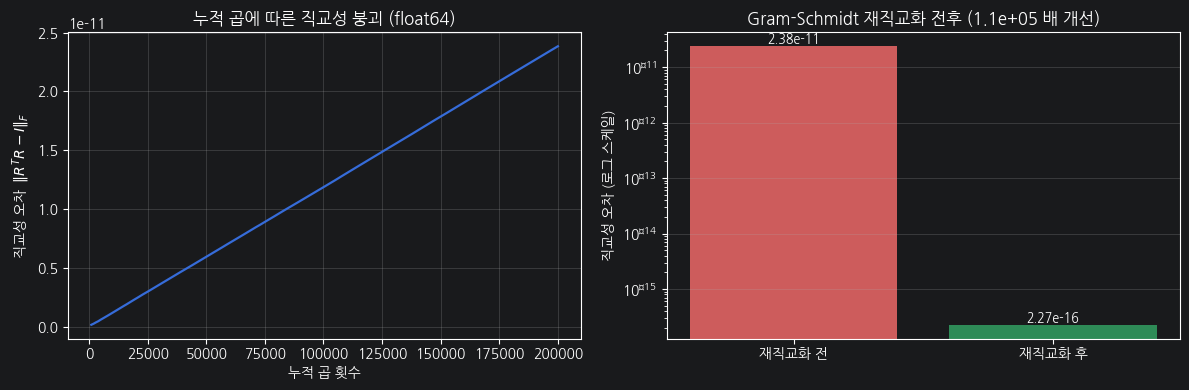

In [7]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_n, history_err, lw=1.6)
axes[0].set_xlabel("누적 곱 횟수")
axes[0].set_ylabel(r"직교성 오차  $\|R^T R - I\|_F$")
axes[0].set_title("누적 곱에 따른 직교성 붕괴 (float64)")
axes[0].grid(alpha=0.3)

labels = ["재직교화 전", "재직교화 후"]
vals = [err_before, max(err_after, 1e-18)]
bars = axes[1].bar(labels, vals, color=["indianred", "seagreen"])
axes[1].set_yscale("log")
axes[1].set_ylabel("직교성 오차 (로그 스케일)")
axes[1].set_title("Gram-Schmidt 재직교화 전후 ({:.1e} 배 개선)".format(improvement))
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, "{:.2e}".format(v),
                 ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [8]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("재직교화 후 오차가 전보다 작다", err_after < err_before)
ok &= check("재직교화 후 오차가 기계정밀도 수준 (< 1e-14)", err_after < 1e-14)
ok &= check("복구 행렬의 행렬식이 1", np.isclose(det_after, 1.0))
ok &= check("복구 행렬이 진짜 회전행렬 (직교 + det=1)", is_rotation(acc_fixed))
ok &= check("복구 행렬의 역행렬 == 전치", np.allclose(np.linalg.inv(acc_fixed), acc_fixed.T))   # 검산용
ok &= check("자세가 크게 바뀌지 않았다 (차이 < 1e-6)", np.max(np.abs(acc_fixed - acc)) < 1e-6)
ok &= check("이미 직교인 행렬에 적용하면 그대로", np.allclose(gram_schmidt(rot_z(0.4)), rot_z(0.4)))
noisy = rot_x(0.3) + 1e-3 * rng.standard_normal((3, 3))
ok &= check("노이즈 섞인 행렬도 회전행렬로 복구", is_rotation(gram_schmidt(noisy)))
print("\n3-2 전체 통과:", ok)

[PASS] 재직교화 후 오차가 전보다 작다
[PASS] 재직교화 후 오차가 기계정밀도 수준 (< 1e-14)
[PASS] 복구 행렬의 행렬식이 1
[PASS] 복구 행렬이 진짜 회전행렬 (직교 + det=1)
[PASS] 복구 행렬의 역행렬 == 전치
[PASS] 자세가 크게 바뀌지 않았다 (차이 < 1e-6)
[PASS] 이미 직교인 행렬에 적용하면 그대로
[PASS] 노이즈 섞인 행렬도 회전행렬로 복구

3-2 전체 통과: True


## 3-3. `tests/test_rotation.py` — pytest 4가지 검증

`tests/test_rotation.py` 템플릿에 다음 네 가지를 작성하세요.

| # | 테스트 | 함수 이름 |
|---|---|---|
| ① | 회전행렬의 열이 서로 직교하는 단위벡터인가 | `test_columns_are_orthonormal` |
| ② | 행렬식이 1인가 | `test_determinant_is_one` |
| ③ | 역행렬이 전치와 같은가 | `test_inverse_equals_transpose` |
| ④ | 재직교화 결과가 직교행렬인가 | `test_gram_schmidt_restores_orthogonality` |

`@pytest.mark.parametrize` 로 축 x 각도를 조합하면 함수 하나가 여러 케이스를 검사합니다.
반사 행렬 반례, 로드리게스 일치, 축·각 왕복 같은 테스트를 더 붙이면 좋습니다.

아래 셀은 노트북 안에서 pytest 를 돌려 **전수 통과 출력을 노트북에 남깁니다.**

In [9]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-v", "--no-header",
     "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(result.stdout[-6000:])
print(result.stderr[-2000:])
print("종료 코드 :", result.returncode)

793-rot_y] PASSED [ 26%]
tests/test_rotation.py::test_columns_are_orthonormal[3.141592653589793-rot_z] PASSED [ 27%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_x] PASSED [ 28%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_y] PASSED [ 30%]
tests/test_rotation.py::test_columns_are_orthonormal[-1.234-rot_z] PASSED [ 31%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_x] PASSED        [ 32%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_y] PASSED        [ 34%]
tests/test_rotation.py::test_determinant_is_one[0.0-rot_z] PASSED        [ 35%]
tests/test_rotation.py::test_determinant_is_one[0.39269908169872414-rot_x] PASSED [ 36%]
tests/test_rotation.py::test_determinant_is_one[0.39269908169872414-rot_y] PASSED [ 38%]
tests/test_rotation.py::test_determinant_is_one[0.39269908169872414-rot_z] PASSED [ 39%]
tests/test_rotation.py::test_determinant_is_one[0.5235987755982988-rot_x] PASSED [ 40%]
tests/test_rotation.py::test_determinant_is_o

In [10]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("pytest 전수 통과 (종료 코드 0)", result.returncode == 0)
ok &= check("실패/에러가 없다", ("failed" not in result.stdout) and ("error" not in result.stdout.lower()))
ok &= check("요구된 4가지 테스트가 모두 존재", all(
    name in result.stdout for name in [
        "test_columns_are_orthonormal",
        "test_determinant_is_one",
        "test_inverse_equals_transpose",
        "test_gram_schmidt_restores_orthogonality",
    ]))
ok &= check("통과 케이스가 4개 이상 (parametrize 권장)", result.stdout.count("PASSED") >= 4)
print("\n3-3 전체 통과:", ok)

[PASS] pytest 전수 통과 (종료 코드 0)
[PASS] 실패/에러가 없다
[PASS] 요구된 4가지 테스트가 모두 존재
[PASS] 통과 케이스가 4개 이상 (parametrize 권장)

3-3 전체 통과: True


## 3-4. 일부러 틀리게 바꿔 보기 — 테스트가 잡아내는가

테스트가 "항상 통과하는 테스트" 가 아니라는 것을 보이려면
**일부러 버그를 넣어 실패하는지** 확인해야 합니다(뮤테이션 테스트의 축소판).

**할 일**

- `rot_z` 등 회전 함수 한 곳을 틀리게 바꿀 치환 문자열을 정하세요
  (예: 부호 하나 뒤집기). 아래 `BUG_FROM` 은 **여러분이 작성한 소스에 실제로
  딱 한 번 등장하는 문자열**이어야 합니다.
- 어떤 성질이 깨질지 **미리 예상**하고, 실제 실패 목록과 비교하세요.
- 아래 셀은 `finally` 에서 반드시 원본으로 되돌립니다. 이 구조를 지우지 마세요.

### 예상과 결과

- 바꾼 내용: `rot_z` (2,1) 성분 `[s, c, 0.0]` → `[s, -c, 0.0]` (부호 뒤집기)
- 깨질 것으로 예상한 성질: 열 직교성, det=1, 역행렬=전치 (rot_z가 들어가는 테스트 전부)
- 실제로 실패한 테스트: 아래 3-4 셀 출력 참조 (test_columns_are_orthonormal 등)

In [11]:
src_path = ROOT / "src" / "rotation.py"
original = src_path.read_text(encoding="utf-8")

# TODO: 여러분의 소스에 맞게 아래 두 문자열을 채우세요.
# rot_z 의 (2,1) 성분 부호를 뒤집으면 직교성·det=1·전치=역행렬이 한꺼번에 깨진다
BUG_FROM = "[s, c, 0.0],"      # 원본에 정확히 한 번 등장하는 줄
BUG_TO = "[s, -c, 0.0],"        # 일부러 틀리게 바꾼 줄

assert original.count(BUG_FROM) == 1, "치환 대상이 정확히 한 곳이어야 합니다"

try:
    src_path.write_text(original.replace(BUG_FROM, BUG_TO), encoding="utf-8")
    broken = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_rotation.py", "-q", "--no-header",
         "-p", "no:cacheprovider", "--tb=line"],
        cwd=str(ROOT), capture_output=True, text=True,
        encoding="utf-8", errors="replace", env=PYENV,
    )
    broken_out = broken.stdout
    broken_code = broken.returncode
finally:
    src_path.write_text(original, encoding="utf-8")     # 반드시 원상복구

print(broken_out[-5000:])
print("종료 코드 :", broken_code, " (0 이 아니어야 정상 — 테스트가 버그를 잡았다는 뜻)")

137 ,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]) = <function inverse_gauss_jordan at 0x71a2b036b2e0>(array([[ 0.33046511,  0.94381821,  0.        ],\n       [-0.94381821, -0.33046511,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]))
     +    and   array([[ 0.33046511, -0.94381821,  0.        ],\n       [ 0.94381821, -0.33046511,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]) = array([[ 0.33046511,  0.94381821,  0.        ],\n       [-0.94381821, -0.33046511,  0.        ],\n       [ 0.        ,  0.        ,  1.        ]]).T
/home/pa/workspaces/pa/source/physicalai-lv1-kimhyunha/lv1_module3/tests/test_rotation.py:78: AssertionError: 역행렬 != 전치
E   AssertionError: theta=0.0
    assert False
     +  where False = <function allclose at 0x71a2b2a73870>(array([[1., 0., 0.],\n       [0., 1., 0.],\n       [0., 0., 1.]]), array([[ 1., -0.,  0.],\n       [ 0., -1.,  0.],\n       [ 0.,  0.,  1.]]))
     +    where <function allclose at 0x71a2b2

In [12]:
# 원상복구 확인 후 다시 전수 통과하는지 (제공 코드)
restored = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
    cwd=str(ROOT), capture_output=True, text=True,
    encoding="utf-8", errors="replace", env=PYENV,
)
print(restored.stdout[-1500:])
print("복구 후 종료 코드 :", restored.returncode)

........................................................................ [ 87%]
..........                                                               [100%]
82 passed in 0.13s

복구 후 종료 코드 : 0


In [13]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("버그를 넣으면 테스트가 실패한다", broken_code != 0)
ok &= check("실패 목록에 요구된 4가지 중 하나 이상이 있다",
            any(name in broken_out for name in [
                "test_columns_are_orthonormal", "test_determinant_is_one",
                "test_inverse_equals_transpose", "test_gram_schmidt_restores_orthogonality"]))
ok &= check("소스가 원본으로 복구되었다", src_path.read_text(encoding="utf-8") == original)
ok &= check("복구 후 전체 테스트 재통과", restored.returncode == 0)
ok &= check("복구된 rot_z 가 실제로 회전행렬이다", is_rotation(rot_z(0.9)))
print("\n3-4 전체 통과:", ok)

[PASS] 버그를 넣으면 테스트가 실패한다
[PASS] 실패 목록에 요구된 4가지 중 하나 이상이 있다
[PASS] 소스가 원본으로 복구되었다
[PASS] 복구 후 전체 테스트 재통과
[PASS] 복구된 rot_z 가 실제로 회전행렬이다

3-4 전체 통과: True


## 답안 템플릿 정리

In [14]:
n_pass = result.stdout.count("PASSED")
summary = f"""
1. 20만 번 누적 후 직교성 오차: {err_before:.3e}   (지표: ||R^T R - I||_F)
   - float32 로 하면: {err32:.3e} (약 {err32 / err_before:.1e} 배)

2. 재직교화 후 오차: {err_after:.3e}  -> 개선 배율: {improvement:.1e} 배
   - 자세 자체의 변화(최대 성분 차이): {np.max(np.abs(acc_fixed - acc)):.3e}

3. 복구 행렬의 행렬식: {det_after:.12f}  (직교 + det=1 이므로 회전행렬인가: {is_rotation(acc_fixed)})

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 {result.returncode}, 통과 케이스 {n_pass} 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 {broken_code}
   - 바꾼 내용: rot_z (2,1) 성분 [s, c, 0.0] -> [s, -c, 0.0] (부호 뒤집기)
   - 실패한 테스트: test_columns_are_orthonormal / test_determinant_is_one / test_inverse_equals_transpose 등
   - 원본 복구 완료 여부: {src_path.read_text(encoding="utf-8") == original}
"""
print(summary)



1. 20만 번 누적 후 직교성 오차: 2.384e-11   (지표: ||R^T R - I||_F)
   - float32 로 하면: 6.085e-03 (약 2.6e+08 배)

2. 재직교화 후 오차: 2.265e-16  -> 개선 배율: 1.1e+05 배
   - 자세 자체의 변화(최대 성분 차이): 5.904e-12

3. 복구 행렬의 행렬식: 1.000000000000  (직교 + det=1 이므로 회전행렬인가: True)

4. pytest -v 전수 통과 출력: 위 3-3 셀 참조 — 종료 코드 0, 통과 케이스 76 개

5. 함수를 틀리게 바꿨을 때 실패 출력: 위 3-4 셀 참조 — 종료 코드 1
   - 바꾼 내용: rot_z (2,1) 성분 [s, c, 0.0] -> [s, -c, 0.0] (부호 뒤집기)
   - 실패한 테스트: test_columns_are_orthonormal / test_determinant_is_one / test_inverse_equals_transpose 등
   - 원본 복구 완료 여부: True

